# Lasso - Simulation Study

In [139]:
### IMPORTS
# Core data manipulation and numerical computing libraries.
import pandas as pd
import numpy as np

# Plotting utilities used throughout the exploratory and final-fit plots.
import matplotlib.pyplot as plt
from IPython.display import display
plt.style.use('default')

# Lasso is the penalized linear regression model studied in this notebook.
from sklearn.linear_model import Lasso

# Model-assessment metric used for every method comparison.
from sklearn.metrics import mean_squared_error

# Resampling utilities for train/test splits.
from sklearn.model_selection import train_test_split

# Pipeline helper lets preprocessing steps and regression models act as one estimator.
from sklearn.pipeline import make_pipeline

# StandardScaler is needed because lasso penalties are sensitive to predictor scale.
from sklearn.preprocessing import StandardScaler


In [140]:
### GLOBAL VARS
# A single seed keeps every random split and simulated data set reproducible.
RANDOM_SEED = 123


In [141]:
def make_sparse_lasso_data(
    n=100,
    p=10,
    n_active=5,
    beta_min=1.0,
    beta_max=5.0,
    noise=1.0,
    random_state=RANDOM_SEED
):
    """Simulate linear regression data with a controllable sparse signal."""

    # Create a reproducible random-number generator for this simulated data set.
    rng = np.random.default_rng(random_state)

    # Generate n observations and p candidate predictors from a standard normal distribution.
    X = rng.normal(0.0, 1.0, size=(n, p))

    # Start with all coefficients equal to zero so most predictors can be irrelevant.
    beta = np.zeros(p)

    # Randomly choose which predictors truly affect the response.
    active_idx = rng.choice(p, size=n_active, replace=False)

    # Draw effect sizes for the active predictors.
    magnitudes = rng.uniform(beta_min, beta_max, size=n_active)

    # Randomly assign positive or negative directions to the true effects.
    signs = rng.choice([-1.0, 1.0], size=n_active)

    # Fill the true coefficient vector only at the active predictor locations.
    beta[active_idx] = magnitudes * signs

    # Generate the response from the linear signal plus Gaussian noise.
    y = X @ beta + rng.normal(0.0, noise, size=n)

    # Store a dataframe version for inspection and readability.
    columns = [f"x{j + 1}" for j in range(p)]
    dat = pd.DataFrame(X, columns=columns)
    dat["y"] = y

    # Return arrays for modeling plus truth objects for checking the simulation design.
    return X, y, beta, active_idx, dat

In [142]:
# Scenario 1: many irrelevant predictors, so stronger lasso shrinkage may help.
X1, y1, beta1, active_idx1, data1 = make_sparse_lasso_data(p=20, n_active=2)

# Scenario 2: most predictors are truly relevant, so too much shrinkage may hurt.
X2, y2, beta2, active_idx2, data2 = make_sparse_lasso_data(p=20, n_active=18)

# Scenario 3: high noise makes overfitting more likely, which can favor more regularization.
X3, y4, beta3, active_idx3, data3 = make_sparse_lasso_data(noise=3)

# Scenario 4: low noise gives the model cleaner signal, so lighter regularization may work well.
X4, y4, beta4, active_idx4, data4 = make_sparse_lasso_data(noise=0.5)

## Lasso Function

In [143]:
def fit_lasso(X, y, alpha, max_iter=10000):
    """Fit lasso at one alpha value and return holdout test MSE."""

    # Split the simulated data into training and testing sets for prediction-error estimation.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        shuffle=True,
        random_state=RANDOM_SEED,
        test_size=0.2
    )

    # Standardize predictors before lasso because the L1 penalty depends on coefficient scale.
    # alpha controls penalty strength: larger alpha creates more shrinkage toward zero.
    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha, max_iter=max_iter)
    )

    # Fit on the training split only, then predict on the held-out test split.
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Mean squared error measures out-of-sample prediction quality for this alpha value.
    mse_vals = mean_squared_error(y_test, preds)

    return float(np.average(mse_vals))

In [144]:
# Smoke-test the lasso helper on the sparse, many-irrelevant-predictor scenario.
# alpha = 0.1 applies a moderate amount of L1 regularization.
fit_lasso(X1, y1, 0.1)

1.1976527731251025

## Simulation Function

In [145]:
# Each scenario overrides selected defaults in make_sparse_lasso_data.
# The goal is to see whether different signal/noise designs favor different alpha values.
scenarios = {
    "many_irrelevant": {"p": 20, "n_active": 2},
    "few_irrelevant": {"p": 20, "n_active": 18},
    "high_noise": {"noise": 3},
    "low_noise": {"noise": 0.5},
    "high_noise_many_irrelevant": {"noise": 3, "p": 20, "n_active": 2}
}

In [146]:
# Candidate lasso penalty values to test.
# A log-spaced grid covers very weak regularization through strong regularization.
# alpha_vec = [0.0001, 0.001, 0.01, 0.25, 0.5, 0.75, 1]
alpha_vec = np.logspace(-4, 1, 100)


In [147]:
def plot_data(scen_name, x_data, y_data):
    """Plot mean test MSE across alpha values for one simulation scenario."""

    # Create one figure per scenario so each penalty curve is easy to inspect.
    plt.figure(figsize=(7, 5))

    # Each point represents the average test MSE across simulation replicates for one alpha.
    plt.scatter(x_data, y_data, color='blue', label='mean test MSE')

    plt.title(scen_name)
    plt.xlabel('alpha value')
    plt.ylabel('MSE')
    plt.legend(fontsize=8)
    plt.show()

In [148]:
def sim_test(scenarios=scenarios, alpha_vec=alpha_vec, reps=100, show_plot=True):
    """Run the lasso penalty simulation across scenarios and alpha values."""

    # res_per_scen stores a nested dictionary for quick lookup by scenario and alpha.
    res_per_scen = {}

    # rows stores the same results in tidy format so they can be converted to a DataFrame.
    rows = []

    # Loop over each simulation scenario, such as high noise or many irrelevant predictors.
    for scen_name, params in scenarios.items():
        print(scen_name, "->", params)

        # Store mean MSE for every alpha within the current scenario.
        res_per_alpha = {}
        mean_mse_list = []

        # Test each lasso penalty value on the same scenario design.
        for a_val in alpha_vec:
            mse_vals = []

            # Repeat the train/test simulation so results are not based on one random data set.
            for rep in range(0, reps):
                X, y, beta, active_idx, data = make_sparse_lasso_data(**params, random_state=rep)
                mse_vals.append(fit_lasso(X, y, a_val))

            # Average replicate-level MSE values to estimate performance for this alpha.
            mean_mse = float(np.average(mse_vals))
            res_per_alpha[a_val] = mean_mse
            mean_mse_list.append(mean_mse)

            # Add a tidy result row for later comparison and best-alpha selection.
            rows.append({
                "scenario": scen_name,
                "alpha": a_val,
                "mean_mse": mean_mse
            })

        # Save all alpha results for the scenario.
        res_per_scen[scen_name] = res_per_alpha

        # Optionally plot the penalty curve for the current scenario.
        if show_plot:
            plot_data(scen_name, alpha_vec, mean_mse_list)

    # Convert the tidy rows to a dataframe for selecting the best alpha per scenario.
    res_df = pd.DataFrame(rows)

    # For each scenario, keep the alpha value with the lowest mean MSE.
    best_per_scen_df = (
        res_df
        .loc[res_df.groupby("scenario")["mean_mse"].idxmin()]
        .reset_index(drop=True)
    )

    return best_per_scen_df, res_per_scen
            
            


many_irrelevant -> {'p': 20, 'n_active': 2}


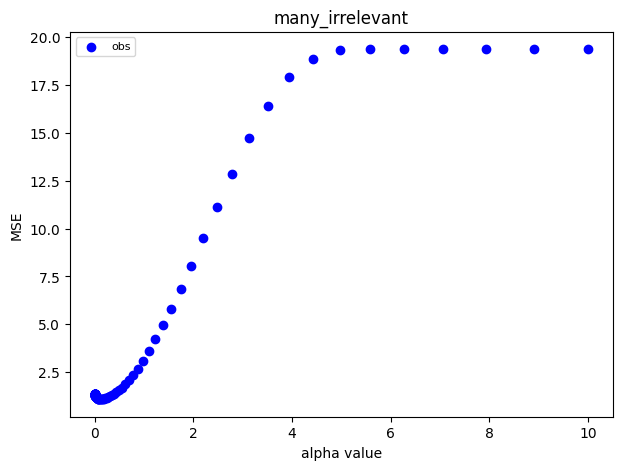

few_irrelevant -> {'p': 20, 'n_active': 18}


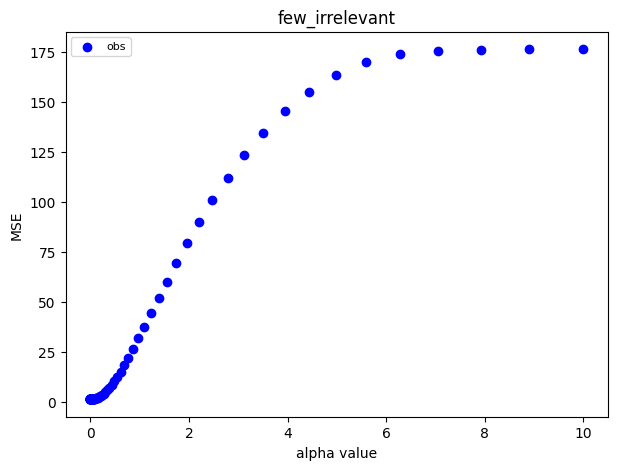

high_noise -> {'noise': 3}


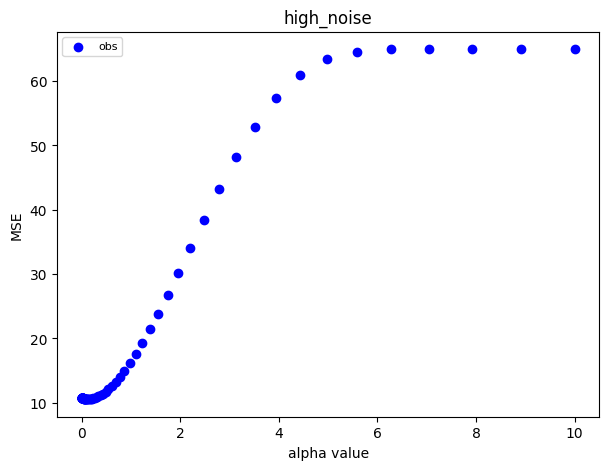

low_noise -> {'noise': 0.5}


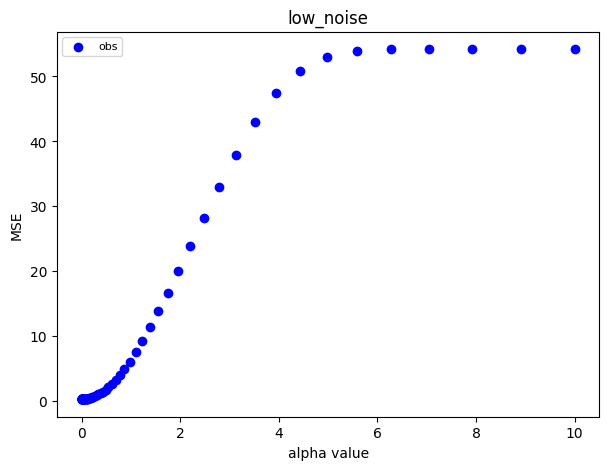

high_noise_many_irrelevant -> {'noise': 3, 'p': 20, 'n_active': 2}


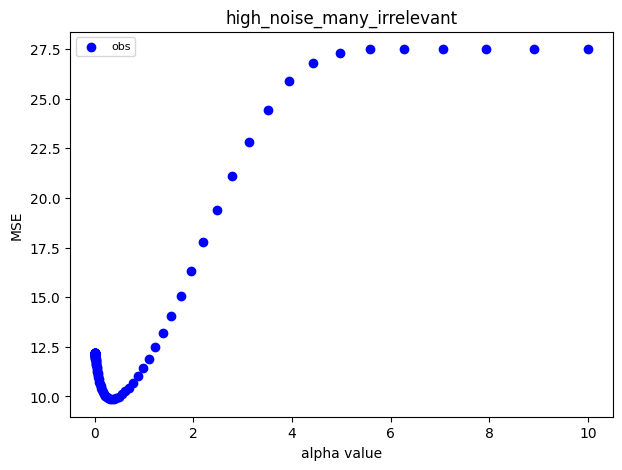

In [149]:
# Run the full lasso simulation study.
# res_df contains the best alpha per scenario, and res_json stores all mean MSE curves.
res_df, res_json = sim_test()

In [150]:
# Display the best alpha and corresponding mean MSE for each scenario.
res_df

,scenario,alpha,mean_mse
0,few_irrelevant,0.009326,1.457571
1,high_noise,0.135305,10.553997
2,high_noise_many_irrelevant,0.343047,9.862786
3,low_noise,0.023645,0.293169
4,many_irrelevant,0.107227,1.096348


## Discussion

Lasso use the L1 norm as a regularizer to push unhelpful feature coefficients toward zero. The strength of the penalty (alpha here) is how aggressively we push - a higher value alpha cooresponds to a stronger push and vice-versa - and is what were are tunning as a hyper parameter in this problem. 

To properly tune, we need to make sure the data is proper standarized as the regularizer is sensitive to scale. For example, if 1 features normal range is 0 - 100 while another is 0 - 1, then without standardization the feature with the larger range will have an arbitratily high weight relative to the feature with smaller range. To mitigate this and make sure all features have the same scale, we use Sklearn's StandardScaler here.

As we can see from the results above, Lasso really shines in the scenarios when we have high noise or many irrelevant feature (or both cases). This statement is supported by the fact that in these cases the optimal alpha value is higher relatively speaking than in the other cases suggesting that regularization provided by Lasso is more helpful there. This makes sense, as Lasso naturally helps to cut through the noise by reducing weighting on features that are unhelpful - in this case either intrinsically unhelpful or too noisy. 

These also illustrates the bias-variance tradeoff especially in the high_noise_many_irrelevant scenario. In this case, we see that when the alpha value is near zero, MSE is relatively high as the model is overly complex and overfitting the training data because we are using too many unhelpful or noisely features. However, as the alpha value increases towards 1 (and beyond) we again see that MSE is relatively high. This time because high bias contributes most to the MSE as the strong regularization forces too many features toward 0 weight and make the model to simple to appropriately model of the information avaliable.  